In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [10]:
gh = np.array([1, 2, 3, 4, 5])
print(gh)

[1 2 3 4 5]


In [11]:
df = pd.read_csv('S02-hw-dataset.csv')
df.columns = df.columns.str.strip()
df.head(2)

,user_id,age,country,purchases,revenue
0,1,25,FR,7,749
1,2,24,RU,5,1115


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   user_id    41 non-null     int64 
 1   age        41 non-null     object
 2   country    41 non-null     object
 3   purchases  41 non-null     int64 
 4   revenue    41 non-null     int64 
dtypes: int64(3), object(2)
memory usage: 1.7+ KB


In [13]:
df.describe()

,user_id,purchases,revenue
count,41.000000,41.000000,41.000000
mean,20.243902,4.829268,820.048780
std,11.659289,2.710189,613.127269
min,1.000000,-1.000000,0.000000
25%,10.000000,3.000000,432.000000
50%,20.000000,5.000000,693.000000
75%,30.000000,7.000000,1115.000000
max,40.000000,11.000000,2475.000000


In [14]:
df['age'] = pd.to_numeric(df['age'], errors='coerce')
df['purchases'] = pd.to_numeric(df['purchases'], errors='coerce')
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')

В данном датасете было нарушено качество данных: полнота, уникальность и валидность. В поле "user_id" нарушена уникальность, в поле "country" нарушена полнота, а в остальных валидность данных

In [15]:
propysk = df["user_id"].isna().sum() + df["age"].isna().sum() + df["country"].isna().sum() + df["purchases"].isna().sum() + df["revenue"].isna().sum()
duplicated_data = df.duplicated().sum()
duplicated_indices = df[df.duplicated(keep='first')].index.tolist()
strange_user_id = (df["user_id"] < 0).sum()
srange_age = ((df["age"] < 0) | (df["age"] > 100)).sum()
strange_country = ((df["country"].str.len() != 2) | (isinstance(df["country"], str) | (not isinstance(df["country"],(int, float))) )).sum()
strange_purchases = (df["purchases"] < 0).sum()
strange_revenue = ((df["revenue"] <= 0)).sum()

print("Индекс дубликатов:", duplicated_indices)
print(f"Количество пропусков в данных: {propysk}, количество дубликатов: {duplicated_data}, количество странных user_id: {strange_user_id}, количество странных age: {srange_age}, количество странных country: {strange_country}, количество странных purchases: {strange_purchases}, количество странных revenue: {strange_revenue}")

Индекс дубликатов: [40]
Количество пропусков в данных: 2, количество дубликатов: 1, количество странных user_id: 0, количество странных age: 1, количество странных country: 41, количество странных purchases: 1, количество странных revenue: 4


In [16]:
cat_age = df["age"].value_counts(bins=[1, 25, 45, 65, 100], sort=False)
cat_country = df["country"].value_counts(sort=True)

group_by_country = (df.groupby("country")["age"].mean()).round(1)
group_by_purchases = df.groupby("country")["purchases"].sum()

print("\n1. Распределение возраста по группам:")
print(cat_age)

print("\n2. Частота встречаемости стран:")
print(cat_country)

print("\n3. Средний возраст по странам:")
print(group_by_country)

print("\n4. Суммарные покупки по странам:")
print(group_by_purchases)


1. Распределение возраста по группам:
(0.999, 25.0]    12
(25.0, 45.0]     17
(45.0, 65.0]      9
(65.0, 100.0]     0
Name: count, dtype: int64

2. Частота встречаемости стран:
country
RU         13
FR         12
US          8
DE          6
CN          2
Name: count, dtype: int64

3. Средний возраст по странам:
country
CN         24.0
DE         34.6
FR         46.2
RU         30.1
US         36.7
Name: age, dtype: float64

4. Суммарные покупки по странам:
country
CN          9
DE         39
FR         51
RU         62
US         37
Name: purchases, dtype: int64


В категориальных данных: в возрасте доминируют люди входящие в возратсной дипазон от 25 до 45 и больше всего встречается пользователей из России.

Группы отличаются по средним значениям: минимальный средний возраст и максимальный средний возраст. В CN 24.0, а в FR 46.2

Неожиданных эффектов не обнаружено 




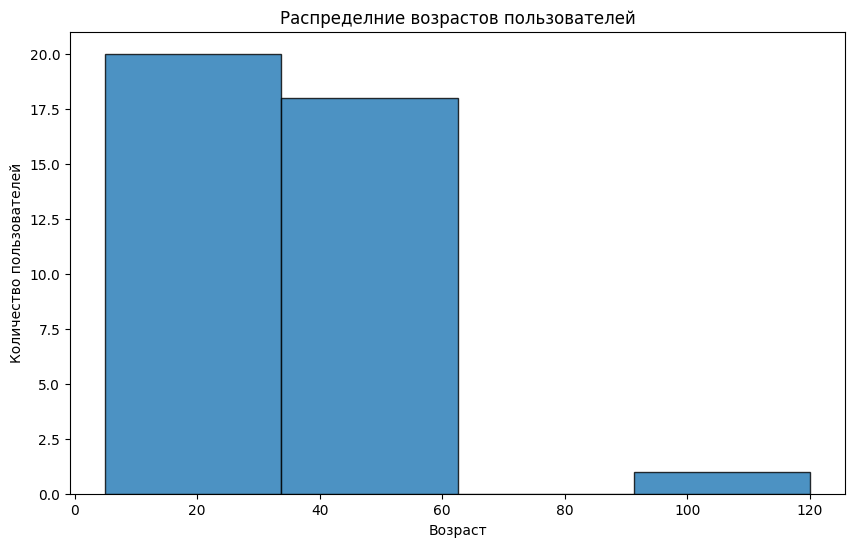

In [ ]:
data_for_hist = df['age']

plt.figure(figsize=(10, 6))

plt.hist(data_for_hist, bins=10, edgecolor='black', alpha=0.8)

plt.title("Распределние возрастов пользователей")
plt.xlabel("Возраст")
plt.ylabel("Количество пользователей")

plt.show()
